# Camada GOLD 

**Perguntas de negócio:**
1. Os 5 órgãos com maior custo total? 
2. Os 3 destinos com maior custo médio por viagem? 
3. A viagem de maior duração e seu custo total? 
4. Qual o tipo de pagamento com maior valor médio? 
5. Qual o meio de transporte mais usado nos trechos? 
6. Qual UF de destino aparece em mais trechos? 
7. Qual órgão pagou mais no total? 

## Conexão com o banco


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', 'scripts')))
import banco

conexao = banco.conectar()

def consultar(sql):
    """Roda um SELECT e devolve o resultado como DataFrame do pandas."""
    return pd.read_sql(sql, conexao)

def reais(valor):
    """Formata um numero como moeda brasileira: 1234.5 -> 'R$ 1.234,50'."""
    texto = f'{valor:,.2f}'
    return 'R$ ' + texto.replace(',', 'X').replace('.', ',').replace('X', '.')

print('Conectado ao MySQL com sucesso.')

Conectado ao MySQL com sucesso.


## Pergunta 1 - Os 5 órgãos com maior custo total? 


**Insights:** O Ministério da Justiça e Segurança Pública é o órgão com maior custo total em viagens, apresentando uma diferença alta para o segundo colocado, o Ministério da Defesa, gastando 3.1 vezes o valor da Defesa. Para entender melhor o motivo desta diferença, seria necessário avaliar, principalmente, a coluna "motivo"

In [6]:
sql_q1 = '''
SELECT 
    nome_orgao_superior AS orgao,
    SUM(valor_total) AS custo_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5;
'''

q1 = consultar(sql_q1)
q1['custo_total_formatado'] = q1['custo_total'].apply(reais)
q1

C:\Users\lilia\AppData\Local\Temp\ipykernel_3168\2649960075.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,orgao,custo_total,custo_total_formatado
0,Ministério da Justiça e Segurança Pública,4.869331e+08,"R$ 486.933.121,65"
1,Ministério da Defesa,1.560703e+08,"R$ 156.070.304,49"
2,Ministério da Educação,1.112913e+08,"R$ 111.291.349,34"
3,Ministério do Meio Ambiente e Mudança do Clima,4.969771e+07,"R$ 49.697.710,16"
4,Ministério da Previdência Social,4.041731e+07,"R$ 40.417.309,06"


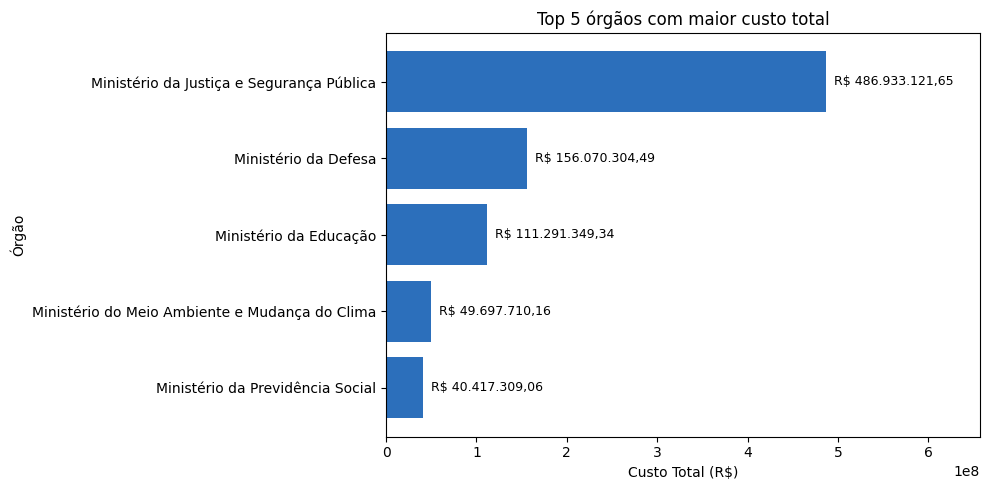

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(q1['orgao'], q1['custo_total'], color='#2c6fbb')
ax.invert_yaxis() 
ax.set_title('Top 5 órgãos com maior custo total')
ax.set_xlabel('Custo Total (R$)')
ax.set_ylabel('Órgão')

# --- Aumentar a margem do eixo X para o texto caber ---
maior_valor = q1['custo_total'].max()
ax.set_xlim(0, maior_valor * 1.35)

for i, (valor_num, valor_txt) in enumerate(zip(q1['custo_total'], q1['custo_total_formatado'])):
    ax.text(valor_num, i, '  ' + valor_txt, va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Pergunta 2 - Os 3 destinos com maior custo médio por viagem? 

Dicas da professora:

Agrupe por `destinos` e use `AVG(valor_total)`. 
Dica: um `HAVING COUNT(*) >= 30` evita que um destino com 1 viagem muito cara distorça o ranking.
Rotation/Sticks: plt.xticks(rotation=15, ha='right')

---
**Insights:**  A questão 2 pode ser calculada de formas diferentes, o que gera, consequentemente, dados diferentes. Da maneira que calculei, os destinos mais caros foram fora do Brasil, o que, de forma lógica, faz sentido. Para informações mais apuradas, poder-se-ia aprofundar a pesquisa neste assunto.

---
### Processo de resolução desta pergunta:

<div style="font-size: 85%; line-height: 1.5;">

#### Primeira query:
A primeira query (agrupamento simples na tabela de viagens): Apresentou erro de digitação na coluna de destino e retornou dados poluídos com escalas duplicadas (ex: Brasília, Brasília). O código pareceu bem simples:

```CREATE OR REPLACE VIEW vw_top3_destinos_custo_viagem AS
SELECT 
    destinos,
    AVG(valor_total) AS custo_medio
FROM silver_viagem
GROUP BY destinos
HAVING COUNT(*) >= 30
ORDER BY custo_medio DESC
LIMIT 3;
```
Mas o resultado foi Brasília para os 3 primeiros destinos com maior custo. Isso aconteceu porque algumas linhas tinham repetições de locais, com base nas paradas feitas (ao que parece).


#### Segunda query:
Então, tentei uma segunda opção:

```CREATE OR REPLACE VIEW vw_top3_destinos_custo_viagem AS
SELECT 
    -- Buscamos a cidade e o estado diretamente da tabela de trechos
    CONCAT(t.destino_cidade, '/', t.destino_uf) AS destino_real,
    AVG(v.valor_total) AS custo_medio
FROM silver_trecho t
INNER JOIN silver_viagem v ON t.id_viagem = v.id_viagem
GROUP BY destino_real
HAVING COUNT(*) >= 30
ORDER BY custo_medio DESC
LIMIT 3;
```

Aqui, porém, o resultado foi estranho:

Monte Negro/Rondônia96133.261104
Sananduva/Rio Grande do Sul95397.809286
Nonoai/Rio Grande do Sul91901.186059

Não parecia fazer sentido destinos nacionais saírem mais caros que internacionais. Ao realizar o JOIN, o custo de uma viagem inteira (que por vezes envolvia grandes comitivas e múltiplos destinos) foi associado de forma integral a cada uma das pequenas paradas individuais. Isso inflou artificialmente o custo médio de cidades pequenas.

#### Terceira query:

```CREATE OR REPLACE VIEW vw_top3_destinos_custo_viagem AS
WITH trechos_calculados AS (
    SELECT 
        id_viagem,
        CONCAT(destino_cidade, '/', destino_uf) AS destino_real,
        -- Conta quantos trechos essa viagem específica teve no total
        COUNT(*) OVER(PARTITION BY id_viagem) AS total_trechos
    FROM silver_trecho
)
SELECT 
    t.destino_real,
    -- Divide o custo total da viagem pela quantidade de trechos que ela teve
    AVG(v.valor_total / t.total_trechos) AS custo_medio_proporcional
FROM trechos_calculados t
INNER JOIN silver_viagem v ON t.id_viagem = v.id_viagem
GROUP BY t.destino_real
HAVING COUNT(*) >= 30
ORDER BY custo_medio_proporcional DESC
LIMIT 3;
```

Aqui o SQL quebrou, porque eu estava tentando fazer as consultas nele para depois vir para o Python. Com isso, eu decidi deixar todas as consultas aqui mesmo. Essa query foi a que mais de satisfez, uma vez que parece real e criou uma média pensando nos pedaços das viagens, e não na linha inteira de destinos.

In [8]:
sql_q2 = '''
SELECT 
    CONCAT(t.destino_cidade, '/', t.destino_uf) AS destino,
    AVG(v.valor_total / counts.total_trechos) AS custo_medio
FROM silver_trecho t
INNER JOIN silver_viagem v ON t.id_viagem = v.id_viagem
INNER JOIN (
    -- Pré-calcula a quantidade de trechos por viagem para ser ultra rápido
    SELECT id_viagem, COUNT(*) AS total_trechos
    FROM silver_trecho
    GROUP BY id_viagem
) counts ON t.id_viagem = counts.id_viagem
GROUP BY destino
HAVING COUNT(*) >= 30
ORDER BY custo_medio DESC
LIMIT 3;
'''

q2 = consultar(sql_q2)

q2['custo_medio_formatado'] = q2['custo_medio'].apply(reais)

q2

C:\Users\lilia\AppData\Local\Temp\ipykernel_3168\2649960075.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino,custo_medio,custo_medio_formatado
0,Genebra/,11427.759816,"R$ 11.427,76"
1,Norfolk-Virginia/,10831.890500,"R$ 10.831,89"
2,Seul/,10690.780851,"R$ 10.690,78"


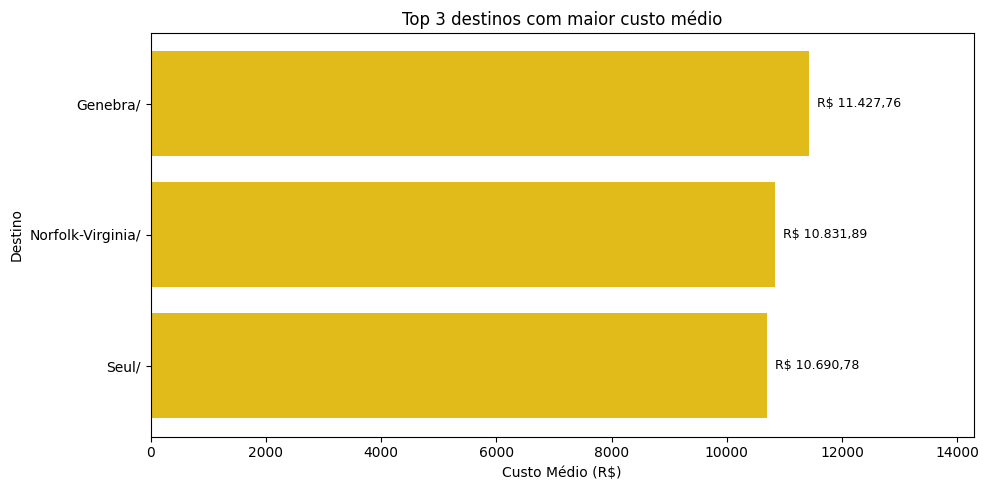

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(q2['destino'], q2['custo_medio'], color="#e0bb19")
ax.invert_yaxis()  # maior em cima
ax.set_title('Top 3 destinos com maior custo médio')
ax.set_xlabel('Custo Médio (R$)')
ax.set_ylabel('Destino')


# --- Aumentar a margem do eixo X para o texto caber ---
maior_valor = q2['custo_medio'].max()
ax.set_xlim(0, maior_valor * 1.25)

for i, (valor_num, valor_txt) in enumerate(zip(q2['custo_medio'], q2['custo_medio_formatado'])):
    ax.text(valor_num, i, '  ' + valor_txt, va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Pergunta 3 - A viagem de maior duração e seu custo total? 

Aqui não parece haver sentido gerar gráfico, já que se pede apenas A viagem mais longa e o custo total dela. Eu tentei gerar um gráfico com as 3 viagens mais longas, mas a segunda e terceira têm dados sigilosos. Não é, em suma, um gráfico muito interessante.

*A resposta é: id: 20699856. Viagem para Mogi Mirim/SP, que durou 383 dias.*

---
**Insights:** A viagem mais longa não possui nenhum gasto, o que parece um pouco contraditório. Olhando com mais cuidado os detalhes do registro, vê-se que o motivo dele é: "Convocar o servidor, para atuação presencial junto á APS Mogi Mirim, nas mesmas atividades que atualmente exercem na lotação de origem". Na verdade, parece tratar-se de um deslocamento de local de trabalho. Neste caso, talvez essa informação não devesse ser tratada como viagem e nem precisaria aparecer neste banco de dados. De qualquer forma, não é possível ter certeza desta inferência e possível erro nos dados sem consultar os órgãos governamentais competentes, o que não cabia ao projeto atual.

In [10]:
sql_q3 = '''
SELECT id_viagem, nome_orgao_superior, destinos, duracao_dias, valor_total
FROM silver_viagem
ORDER BY duracao_dias DESC
LIMIT 1;
'''

q3 = consultar(sql_q3)
q3

C:\Users\lilia\AppData\Local\Temp\ipykernel_3168\2649960075.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,id_viagem,nome_orgao_superior,destinos,duracao_dias,valor_total
0,0000000000020699856,Ministério da Previdência Social,Mogi Mirim/SP,383,0.0


C:\Users\lilia\AppData\Local\Temp\ipykernel_3168\2649960075.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


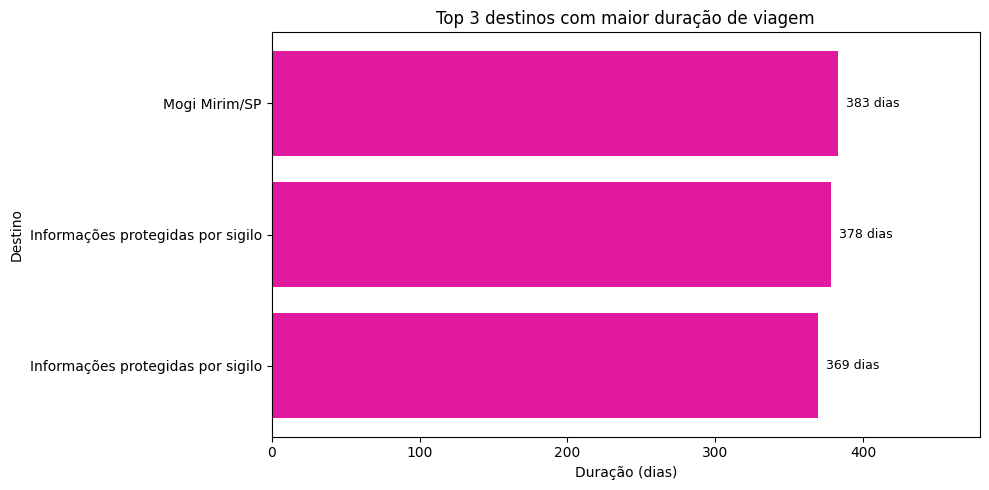

In [11]:
#Gerar gráfico com um só resultado não faz sentido, então aqui fiz uma nova query com os 3 destinos com maior duração de viagem
#a título de curiosidade e comparação.

sql_q3 = '''
SELECT id_viagem, destinos, duracao_dias, valor_total
FROM silver_viagem
ORDER BY duracao_dias DESC
LIMIT 3;
'''

q3 = consultar(sql_q3)


#Gráfico

fig, ax = plt.subplots(figsize=(10, 5))

posicoes_y = range(len(q3))
ax.barh(posicoes_y, q3['duracao_dias'], color="#e0199e")

ax.set_yticks(posicoes_y)
ax.set_yticklabels(q3['destinos'])

ax.invert_yaxis() 
ax.set_title('Top 3 destinos com maior duração de viagem')
ax.set_xlabel('Duração (dias)')
ax.set_ylabel('Destino')

# --- Aumentei a margem do eixo X para o texto caber ---
maior_valor = q3['duracao_dias'].max()
ax.set_xlim(0, maior_valor * 1.25)

q3['duracao_dias_formatada'] = q3['duracao_dias'].astype(str)

for i, (valor_num, valor_txt) in enumerate(zip(q3['duracao_dias'], q3['duracao_dias_formatada'])):
    ax.text(valor_num, i, '  ' + valor_txt + ' dias', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Pergunta 4 - Qual o tipo de pagamento com maior valor médio? 

Aqui o processo é muito parecido com o da questão anterior. Busca-se o tipo de pagamento com maior valor médio, o que não é um comparativo com os outros. Por isso, também fiz uma nova query para a geração de um gráfico. Aqui foi necessário arredondar os valores ára duas casas decimais.

De qualquer forma, *a resposta é 'diárias'.*

---
**Insights:** Na pergunta 4, existem apenas 4 meios de pagamento. Em sequência descrescente, eles são: diárias (R$ 2.078,28), passagem (R$ 1.878,34), serviço correlato - seguro ($ 447,51) e restituição (R$ 245,70). Esses itens mais parecem categorias do que formas de pagamento, não tendo formas mais clásssicas como cartão de crédito, pix, ou correlatos.

In [12]:
sql_q4 = '''
SELECT tipo_pagamento,
    ROUND(AVG(valor), 2) AS valor_medio
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC
LIMIT 1;
'''

q4 = consultar(sql_q4)
q4


C:\Users\lilia\AppData\Local\Temp\ipykernel_3168\2649960075.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,tipo_pagamento,valor_medio
0,DIÁRIAS,2078.28


C:\Users\lilia\AppData\Local\Temp\ipykernel_3168\2649960075.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


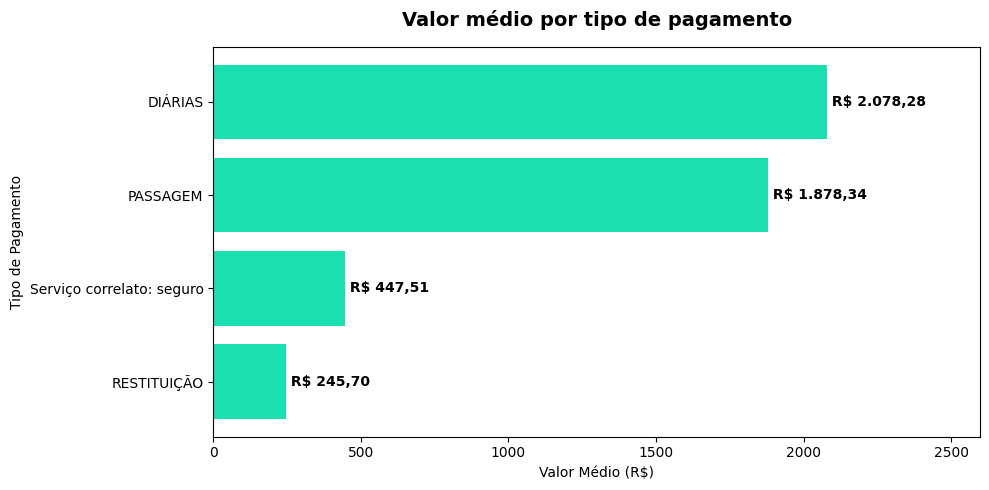

In [13]:
sql_q4 = '''
SELECT tipo_pagamento,
       ROUND(AVG(valor), 2) AS valor_medio
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC
LIMIT 4;
'''

q4 = consultar(sql_q4)
q4

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(10, 5))

posicoes_y = range(len(q4))
ax.barh(posicoes_y, q4['valor_medio'], color="#19e0ae")

ax.set_yticks(posicoes_y)
ax.set_yticklabels(q4['tipo_pagamento'])

ax.invert_yaxis() 
ax.set_title('Valor médio por tipo de pagamento', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Valor Médio (R$)')
ax.set_ylabel('Tipo de Pagamento')

# --- Aumentar a margem do eixo X para o texto caber ---
maior_valor = q4['valor_medio'].max()
ax.set_xlim(0, maior_valor * 1.25)

for i, valor_num in enumerate(q4['valor_medio']):
    valor_formatado = f" R$ {valor_num:,.2f}".replace('.', '@').replace(',', '.').replace('@', ',')
    ax.text(valor_num, i, valor_formatado, va='center', fontsize=10, fontweight='semibold')

plt.tight_layout()
plt.show()

## Pergunta 5 - Qual o meio de transporte mais usado nos trechos? 

Mesma coisa das questões 3 e 4. Busca-se o tipo meio de transporte mais usado, o que não é um comparativo com os outros. Para uma análise mais apurada, fez-se uma nova query para encontrar todas as categorias e depois fez-se a criação do gráfico mostrando os meios mais usados, em ordem decrescente.

*A resposta é 'Veículo Oficial'.*

---
**Insights:** Em relação à pergunta 5, percebe-se que o meio de transporte mais usado para as viagens é o veículo próprio, mas cabe destaque também o meio aéreo. Juntos, eles representam em torno de 80% do total das viagens.


In [14]:
sql_q5 = '''

SELECT meio_transporte,
       COUNT(DISTINCT id_viagem) AS qtde_viagens
FROM silver_trecho
GROUP BY meio_transporte
ORDER BY qtde_viagens DESC
LIMIT 1;
'''

q5 = consultar(sql_q5)
q5

C:\Users\lilia\AppData\Local\Temp\ipykernel_3168\2649960075.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,meio_transporte,qtde_viagens
0,Veículo Oficial,153018


In [15]:
sql_q5 = '''

SELECT DISTINCT (meio_transporte) FROM silver_trecho;

'''

q5 = consultar(sql_q5)
q5

#Há 7 meios de transporte listados: fluvial, aéreo rodoviário, ferroviário, veículo oficial, inválido, veículo próprio, marítimo.

C:\Users\lilia\AppData\Local\Temp\ipykernel_3168\2649960075.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,meio_transporte
0,Fluvial
1,Aéreo
2,Rodoviário
3,Ferroviário
4,Veículo Oficial
5,Inválido
6,Veículo Próprio
7,Marítimo


C:\Users\lilia\AppData\Local\Temp\ipykernel_3168\2649960075.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


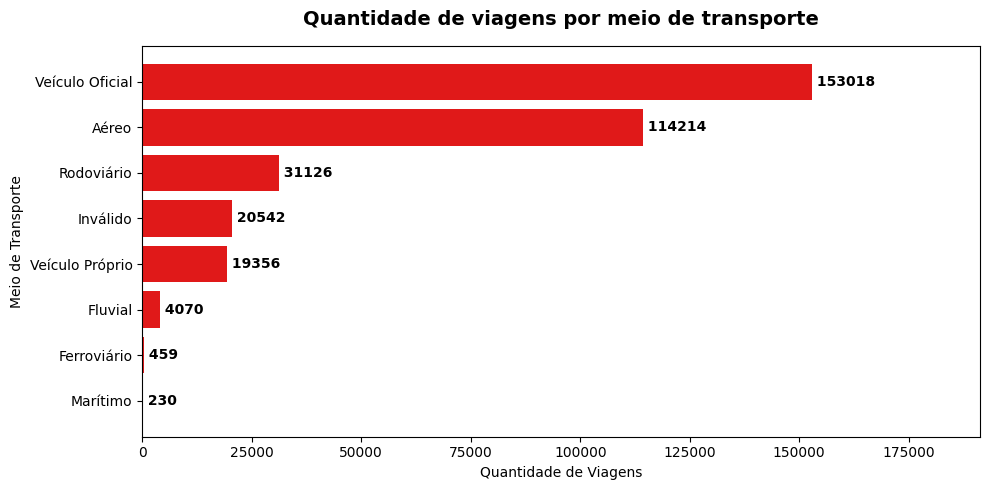

In [16]:
sql_q5 = '''

SELECT meio_transporte,
       COUNT(DISTINCT id_viagem) AS qtde_viagens
FROM silver_trecho
GROUP BY meio_transporte
ORDER BY qtde_viagens DESC;
'''

q5 = consultar(sql_q5)
q5


#Gráfico

fig, ax = plt.subplots(figsize=(10, 5))

posicoes_y = range(len(q5))
ax.barh(posicoes_y, q5['qtde_viagens'], color="#e01919")

ax.set_yticks(posicoes_y)
ax.set_yticklabels(q5['meio_transporte'])

ax.invert_yaxis() 
ax.set_title('Quantidade de viagens por meio de transporte', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Quantidade de Viagens')
ax.set_ylabel('Meio de Transporte')

# --- Aumentar a margem do eixo X para o texto caber ---
maior_valor = q5['qtde_viagens'].max()
ax.set_xlim(0, maior_valor * 1.25)

for i, valor_num in enumerate(q5['qtde_viagens']):
    valor_formatado = f" {valor_num }".replace('.', '@').replace(',', '.').replace('@', ',')
    ax.text(valor_num, i, valor_formatado, va='center', fontsize=10, fontweight='semibold')

plt.tight_layout()
plt.show()


In [17]:
sql_q5 = '''
SELECT 
    meio_transporte,
    COUNT(*) AS qtde_viagens,
    ROUND((COUNT(*) * 100.0) / SUM(COUNT(*)) OVER(), 2) AS porcentagem
FROM silver_trecho
GROUP BY meio_transporte
ORDER BY qtde_viagens DESC;
'''

q5 = consultar(sql_q5)

display(q5)

C:\Users\lilia\AppData\Local\Temp\ipykernel_3168\2649960075.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,meio_transporte,qtde_viagens,porcentagem
0,Veículo Oficial,386424,50.62
1,Aéreo,232666,30.48
2,Rodoviário,64970,8.51
3,Veículo Próprio,42846,5.61
4,Inválido,26659,3.49
5,Fluvial,8429,1.10
6,Ferroviário,874,0.11
7,Marítimo,481,0.06


## Pergunta 6 - Qual UF de destino aparece em mais trechos? 

Mesma coisa das questões 3 a 5. Posteriormente, fez-se a análise com os top 5 destinos e criação de gráfico. Nesse passo importei o Seaborn para poder usar as paletas de cores dele, que são mais bonitas (na minha humilde opinião).

*A resposta é 'Distrito Federal'*.

---
**Insights:** Já a questão 6 mostra que o destino mais frequente é o Distrito Federal, o que faz total sentido, já que é a capital do Brasil. DF é seguido por São Paulo e Rio de Janeiro, todas as 3 sendo capitais importantes para o país, em vários aspectos. É importante frisar, porém, que há uma diferença significativa entre o número de viagens ao DF (72297) em relação a SP (46392).

In [18]:
sql_q6 = '''

SELECT destino_uf,
       COUNT(DISTINCT id_viagem) AS qtde_viagens
FROM silver_trecho
GROUP BY destino_uf
ORDER BY qtde_viagens DESC
LIMIT 1;
'''

q6 = consultar(sql_q6)
q6

C:\Users\lilia\AppData\Local\Temp\ipykernel_3168\2649960075.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino_uf,qtde_viagens
0,Distrito Federal,72297


C:\Users\lilia\AppData\Local\Temp\ipykernel_3168\2649960075.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


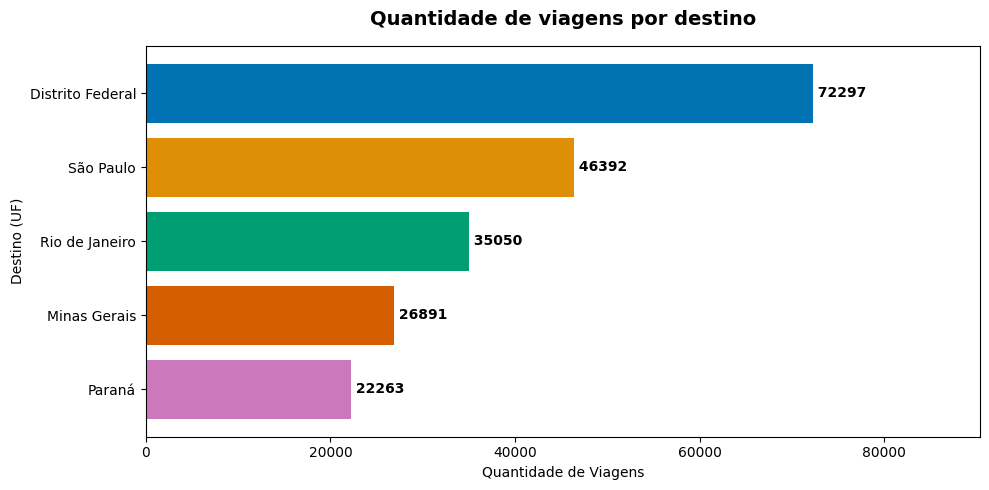

In [19]:
sql_q6 = '''

SELECT destino_uf,
       COUNT(DISTINCT id_viagem) AS qtde_viagens
FROM silver_trecho
GROUP BY destino_uf
ORDER BY qtde_viagens DESC
LIMIT 5;
'''

q6 = consultar(sql_q6)
q6


#Gráfico

import seaborn as sns


fig, ax = plt.subplots(figsize=(10, 5))

cores_seaborn = sns.color_palette("colorblind", len(q6))

posicoes_y = range(len(q6))
ax.barh(posicoes_y, q6['qtde_viagens'], color=cores_seaborn)

ax.set_yticks(posicoes_y)
ax.set_yticklabels(q6['destino_uf'])

ax.invert_yaxis() 
ax.set_title('Quantidade de viagens por destino', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Quantidade de Viagens')
ax.set_ylabel('Destino (UF)')

# --- Aumentar a margem do eixo X para o texto caber ---
maior_valor = q6['qtde_viagens'].max()
ax.set_xlim(0, maior_valor * 1.25)

for i, valor_num in enumerate(q6['qtde_viagens']):
    valor_formatado = f" {valor_num }".replace('.', '@').replace(',', '.').replace('@', ',')
    ax.text(valor_num, i, valor_formatado, va='center', fontsize=10, fontweight='semibold')

plt.tight_layout()
plt.show()

## Pergunta 7 - Qual órgão pagou mais no total? 

Nesta última pergunta de negócio, o processo é o mesmo. Busca-se o órgao (superior) que teve maior gasto total. Aqui foi necessário arredondar o valor para duas casas decimais. Para gerar comparativo, criei uma nova query e gerei gráfico de barras também. 

*A resposta é: 4.869331e+08 = R$ 486.933.100,00*

---
**Insights:** Quanto à última pergunta de negócio, o órgão superior com mais gastos foi o Ministério da Justiça e Segurança Pública, o que ecoa o resultado da primeira questão: se há mais viagens, é lógico imaginar que o custo também é maior para este órgão.

In [20]:
sql_q7 = '''

SELECT nome_orgao_superior,
       ROUND(SUM(valor_total), 2) AS valor_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY valor_total DESC
LIMIT 1;
'''

q7 = consultar(sql_q7)
q7

C:\Users\lilia\AppData\Local\Temp\ipykernel_3168\2649960075.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,nome_orgao_superior,valor_total
0,Ministério da Justiça e Segurança Pública,4.869331e+08


C:\Users\lilia\AppData\Local\Temp\ipykernel_3168\2649960075.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


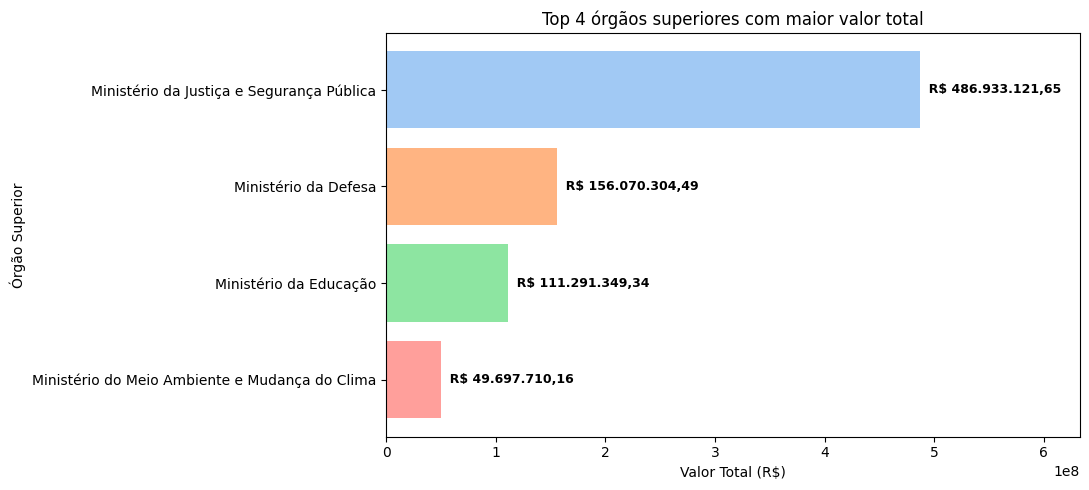

In [21]:
import seaborn as sns 


sql_q7 = '''
SELECT nome_orgao_superior,
       ROUND(SUM(valor_total), 2) AS valor_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY valor_total DESC
LIMIT 4;
'''

q7 = consultar(sql_q7)

q7['valor_total_formatado'] = q7['valor_total'].apply(reais)


#Gráfico

fig, ax = plt.subplots(figsize=(11, 5))

cores_seaborn = sns.color_palette("pastel", len(q7))

posicoes_y = range(len(q7))

ax.barh(posicoes_y, q7['valor_total'], color=cores_seaborn)

ax.set_yticks(posicoes_y)
ax.set_yticklabels(q7['nome_orgao_superior'])

ax.invert_yaxis() 
ax.set_title('Top 4 órgãos superiores com maior valor total')
ax.set_xlabel('Valor Total (R$)')
ax.set_ylabel('Órgão Superior')

maior_valor = q7['valor_total'].max()
ax.set_xlim(0, maior_valor * 1.3)

for i, (valor_num, valor_txt) in enumerate(zip(q7['valor_total'], q7['valor_total_formatado'])):
    ax.text(valor_num, i, '  ' + valor_txt, va='center', fontsize=9, fontweight='semibold')

plt.tight_layout()
plt.show()

## Etapa Gold

Para abarcar todos os critérios de avaliação, realizei a criação de tabela gold focando no total de passagens emitidas x nome dos ógãos que as emitiram. O código sql para criação desta tabela gold e sua view estão no arquivo `gold.sql`.

---
**Insights:** No gráfico é possível perceber que o Ministério da Defesa é o que tem mais passagens emitidas, o que coindice com os gráficos da pergunta 1 e 7, apesar de, nestes casos, ter ficado em segundo lugar. Ainda assim, valor gasto pode estar diretamente relacionado à quantidade de passagens emitidas. Para haver certeza, só fazendo uma análise mais profunda neste quesito.

In [22]:
import pandas as pd
from banco import conectar

conexao = conectar()

etapa_gold = """
SELECT 
    nome_orgao_superior,
    valor_medio_passagem,
    total_passagens_emitidas
FROM tb_passagens_emitidas_gold
LIMIT 5;
"""

df_gold = pd.read_sql(etapa_gold, conexao)

df_gold

C:\Users\lilia\AppData\Local\Temp\ipykernel_3168\518625003.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_gold = pd.read_sql(etapa_gold, conexao)


,nome_orgao_superior,valor_medio_passagem,total_passagens_emitidas
0,Ministério da Educação,1696.37,29981
1,Ministério da Defesa,1637.54,38038
2,Ministério da Saúde,1987.94,9883
3,Advocacia-Geral da União,1190.97,1962
4,Ministério de Portos e Aeroportos,1341.28,4036


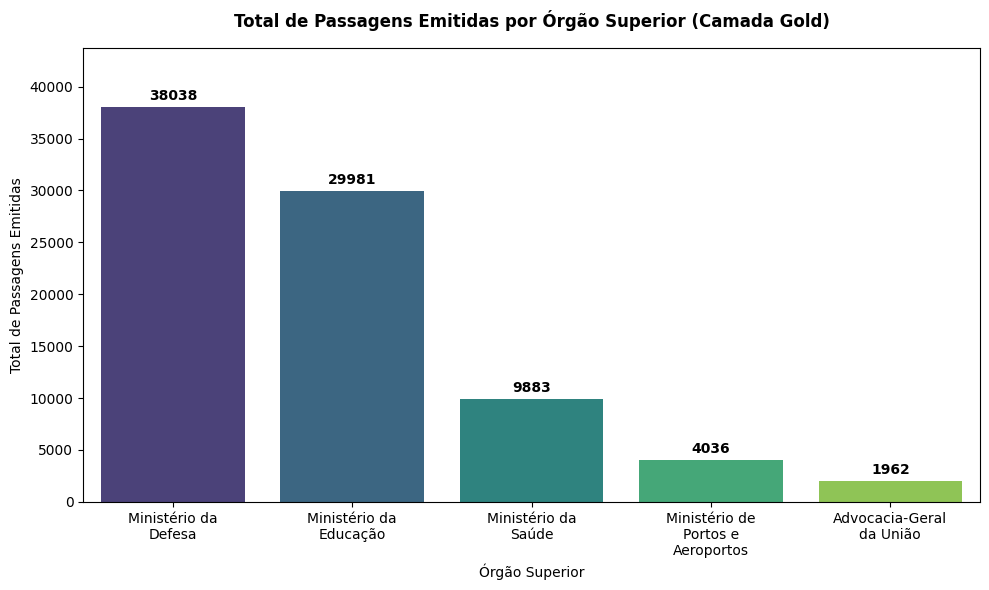

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns 
import textwrap 

df_plot = df_gold.copy() 
df_plot = df_plot.sort_values(by='total_passagens_emitidas', ascending=False)

df_plot['orgao_quebrado'] = df_plot['nome_orgao_superior'].apply(lambda x: textwrap.fill(x, width=15))

fig, ax = plt.subplots(figsize=(10, 6))

bars = sns.barplot(
    data=df_plot, 
    x='orgao_quebrado', 
    y='total_passagens_emitidas', 
    hue='orgao_quebrado',  
    order=df_plot['orgao_quebrado'],  
    palette='viridis',  
    legend=False,         
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=10, fontweight='bold')

plt.title('Total de Passagens Emitidas por Órgão Superior (Camada Gold)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Órgão Superior', fontsize=10)
plt.ylabel('Total de Passagens Emitidas', fontsize=10)

plt.ylim(0, df_plot['total_passagens_emitidas'].max() * 1.15)

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()